In [17]:
import pandas as pd

# CSV 파일 경로
file_path = "marketing_campaign.csv"

# 데이터 불러오기
df = pd.read_csv(file_path, sep='\t')  # 탭 구분자로 되어 있음

In [18]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [19]:
# 데이터 기본 정보 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [20]:
# 결측치 확인
missing_summary = df.isnull().sum()

missing_summary

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

## 분석 계획(반영된 분석법 3개)

| 분석 기법 | 변수 조합 | 분석 목적 |
| --- | --- | --- |
| **t-test** | `Recency` vs `Response` | 응답자와 비응답자의 최근 구매일 차이 검정 |
| **ANOVA** | `NumWebPurchases` vs `Kidhome` | 자녀 수에 따라 웹 구매 수 평균 차이 검정 |
| **카이제곱** | `Education` vs `Response` | 교육 수준과 캠페인 응답 간 독립성 검정 |

In [21]:
# 분석에 불필요한 열 제거: ID, Dt_Customer, Z_CostContact, Z_Revenue 등
drop_cols = ['ID', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue']
df_cleaned = df.drop(columns=drop_cols)

df_cleaned

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,1957,Graduation,Single,58138.0,0,0,58,635,88,546,...,10,4,7,0,0,0,0,0,0,1
1,1954,Graduation,Single,46344.0,1,1,38,11,1,6,...,1,2,5,0,0,0,0,0,0,0
2,1965,Graduation,Together,71613.0,0,0,26,426,49,127,...,2,10,4,0,0,0,0,0,0,0
3,1984,Graduation,Together,26646.0,1,0,26,11,4,20,...,0,4,6,0,0,0,0,0,0,0
4,1981,PhD,Married,58293.0,1,0,94,173,43,118,...,3,6,5,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,Graduation,Married,61223.0,0,1,46,709,43,182,...,3,4,5,0,0,0,0,0,0,0
2236,1946,PhD,Together,64014.0,2,1,56,406,0,30,...,2,5,7,0,0,0,1,0,0,0
2237,1981,Graduation,Divorced,56981.0,0,0,91,908,48,217,...,3,13,6,0,1,0,0,0,0,0
2238,1956,Master,Together,69245.0,0,1,8,428,30,214,...,5,10,3,0,0,0,0,0,0,0


In [22]:
# Income 결측치 제거
df_cleaned = df_cleaned.dropna(subset=['Income'])

df_cleaned

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,1957,Graduation,Single,58138.0,0,0,58,635,88,546,...,10,4,7,0,0,0,0,0,0,1
1,1954,Graduation,Single,46344.0,1,1,38,11,1,6,...,1,2,5,0,0,0,0,0,0,0
2,1965,Graduation,Together,71613.0,0,0,26,426,49,127,...,2,10,4,0,0,0,0,0,0,0
3,1984,Graduation,Together,26646.0,1,0,26,11,4,20,...,0,4,6,0,0,0,0,0,0,0
4,1981,PhD,Married,58293.0,1,0,94,173,43,118,...,3,6,5,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,Graduation,Married,61223.0,0,1,46,709,43,182,...,3,4,5,0,0,0,0,0,0,0
2236,1946,PhD,Together,64014.0,2,1,56,406,0,30,...,2,5,7,0,0,0,1,0,0,0
2237,1981,Graduation,Divorced,56981.0,0,0,91,908,48,217,...,3,13,6,0,1,0,0,0,0,0
2238,1956,Master,Together,69245.0,0,1,8,428,30,214,...,5,10,3,0,0,0,0,0,0,0


In [23]:
# 데이터 타입 재확인 및 기본 통계 확인
df_cleaned.info(), df_cleaned.describe()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2216 entries, 0 to 2239
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2216 non-null   int64  
 1   Education            2216 non-null   object 
 2   Marital_Status       2216 non-null   object 
 3   Income               2216 non-null   float64
 4   Kidhome              2216 non-null   int64  
 5   Teenhome             2216 non-null   int64  
 6   Recency              2216 non-null   int64  
 7   MntWines             2216 non-null   int64  
 8   MntFruits            2216 non-null   int64  
 9   MntMeatProducts      2216 non-null   int64  
 10  MntFishProducts      2216 non-null   int64  
 11  MntSweetProducts     2216 non-null   int64  
 12  MntGoldProds         2216 non-null   int64  
 13  NumDealsPurchases    2216 non-null   int64  
 14  NumWebPurchases      2216 non-null   int64  
 15  NumCatalogPurchases  2216 non-null   i

(None,
         Year_Birth         Income      Kidhome     Teenhome      Recency  \
 count  2216.000000    2216.000000  2216.000000  2216.000000  2216.000000   
 mean   1968.820397   52247.251354     0.441787     0.505415    49.012635   
 std      11.985554   25173.076661     0.536896     0.544181    28.948352   
 min    1893.000000    1730.000000     0.000000     0.000000     0.000000   
 25%    1959.000000   35303.000000     0.000000     0.000000    24.000000   
 50%    1970.000000   51381.500000     0.000000     0.000000    49.000000   
 75%    1977.000000   68522.000000     1.000000     1.000000    74.000000   
 max    1996.000000  666666.000000     2.000000     2.000000    99.000000   
 
           MntWines    MntFruits  MntMeatProducts  MntFishProducts  \
 count  2216.000000  2216.000000      2216.000000      2216.000000   
 mean    305.091606    26.356047       166.995939        37.637635   
 std     337.327920    39.793917       224.283273        54.752082   
 min       0.00000

### 결측치 처리

- `Income` 변수에서 결측치 24개 제거
- 최종 행 개수: **2,216개**

### 열 제거 (분석에 불필요한 변수)

- `ID`: 단순 식별자
- `Dt_Customer`: 문자열 날짜 정보 (분석과 직접 관련 없음)
- `Z_CostContact`, `Z_Revenue`: 모두 동일한 값으로 의미 없음

### 데이터 형태 요약

- **수치형 변수**: 22개 (`Income`, `Recency`, `NumWebPurchases` 등)
- **범주형 변수**: 2개 (`Education`, `Marital_Status`)
- **이진 분류 타깃**: `Response`

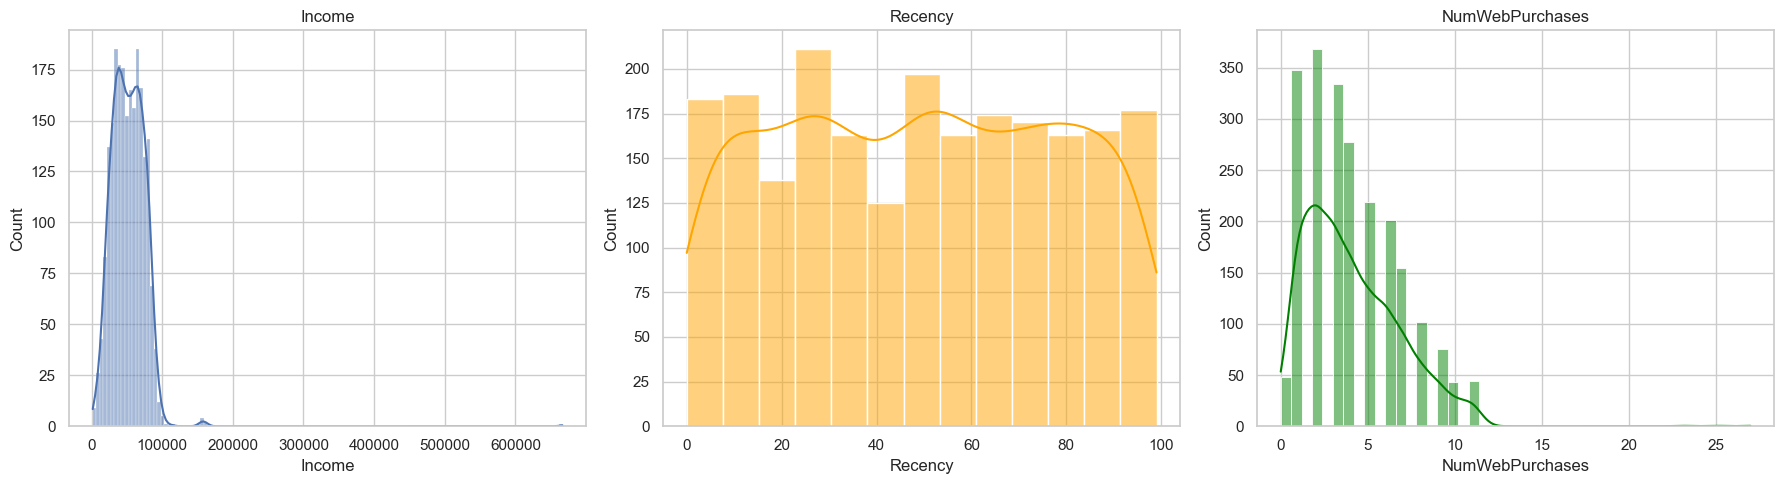

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화 스타일 설정
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 수치형 변수 중 주요 분석 대상 시각화: Income, Recency, NumWebPurchases
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Income 분포
sns.histplot(df_cleaned['Income'], kde=True, ax=axes[0])
axes[0].set_title("Income")

# Recency 분포
sns.histplot(df_cleaned['Recency'], kde=True, ax=axes[1], color='orange')
axes[1].set_title("Recency")

# NumWebPurchases 분포
sns.histplot(df_cleaned['NumWebPurchases'], kde=True, ax=axes[2], color='green')
axes[2].set_title("NumWebPurchases")

plt.tight_layout()
plt.show()


## 탐색적 데이터 분석 (EDA): 수치형 변수 분포

### 1. **Income 분포**

- 전반적으로 **오른쪽으로 치우친 분포 (Right-skewed)** 형태
- 대부분의 고객이 **10만 이하** 소득을 가짐
- 이상치 존재 가능 (최대값 666,666)

### 2. **Recency 분포**

- 고객의 마지막 구매일로부터의 일 수
- **0~100 범위에 균일하게 분포**하는 경향
- 캠페인 대상자 전체가 다양한 구매 시점을 가짐

### 3. **NumWebPurchases 분포**

- 웹 구매 횟수는 전반적으로 **중간 정도의 값(3~7회)**에 집중됨
- 일부 고객은 10회 이상 높은 웹 구매 빈도 보임

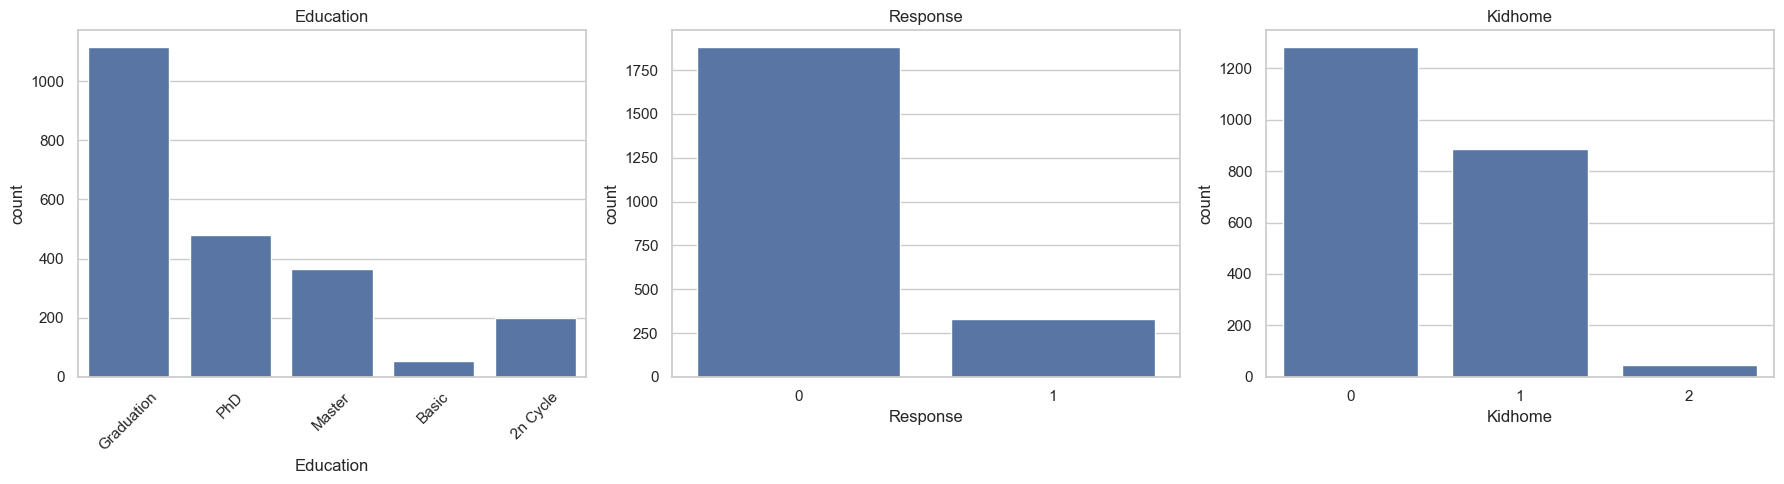

In [47]:
# 범주형 변수 분포 시각화: Education, Response, Kidhome
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Education 분포
sns.countplot(data=df_cleaned, x='Education', ax=axes[0])
axes[0].set_title("Education")
axes[0].tick_params(axis='x', rotation=45)

# Response 분포
sns.countplot(data=df_cleaned, x='Response', ax=axes[1])
axes[1].set_title("Response")

# Kidhome 분포
sns.countplot(data=df_cleaned, x='Kidhome', ax=axes[2])
axes[2].set_title("Kidhome")

plt.tight_layout()
plt.show()


## 탐색적 데이터 분석 (EDA): 범주형 변수 분포

### 1. **Education 분포**

- 대부분의 고객이 **Graduation** 이상 학력을 보유
- `PhD > Graduation > Master > 2n Cycle > Basic` 순으로 분포
- 학력 수준이 대체로 높은 편

### 2. **Response 분포** (캠페인 응답 여부)

- **0 (비응답)** 비율이 압도적으로 많음
- 약 15%만이 캠페인에 **긍정 응답**

### 3. **Kidhome 분포** (자녀 수)

- *자녀가 없는 경우 (0)**가 과반수
- 자녀 1명, 2명의 경우도 고르게 분포됨 → **ANOVA 분석 가능**

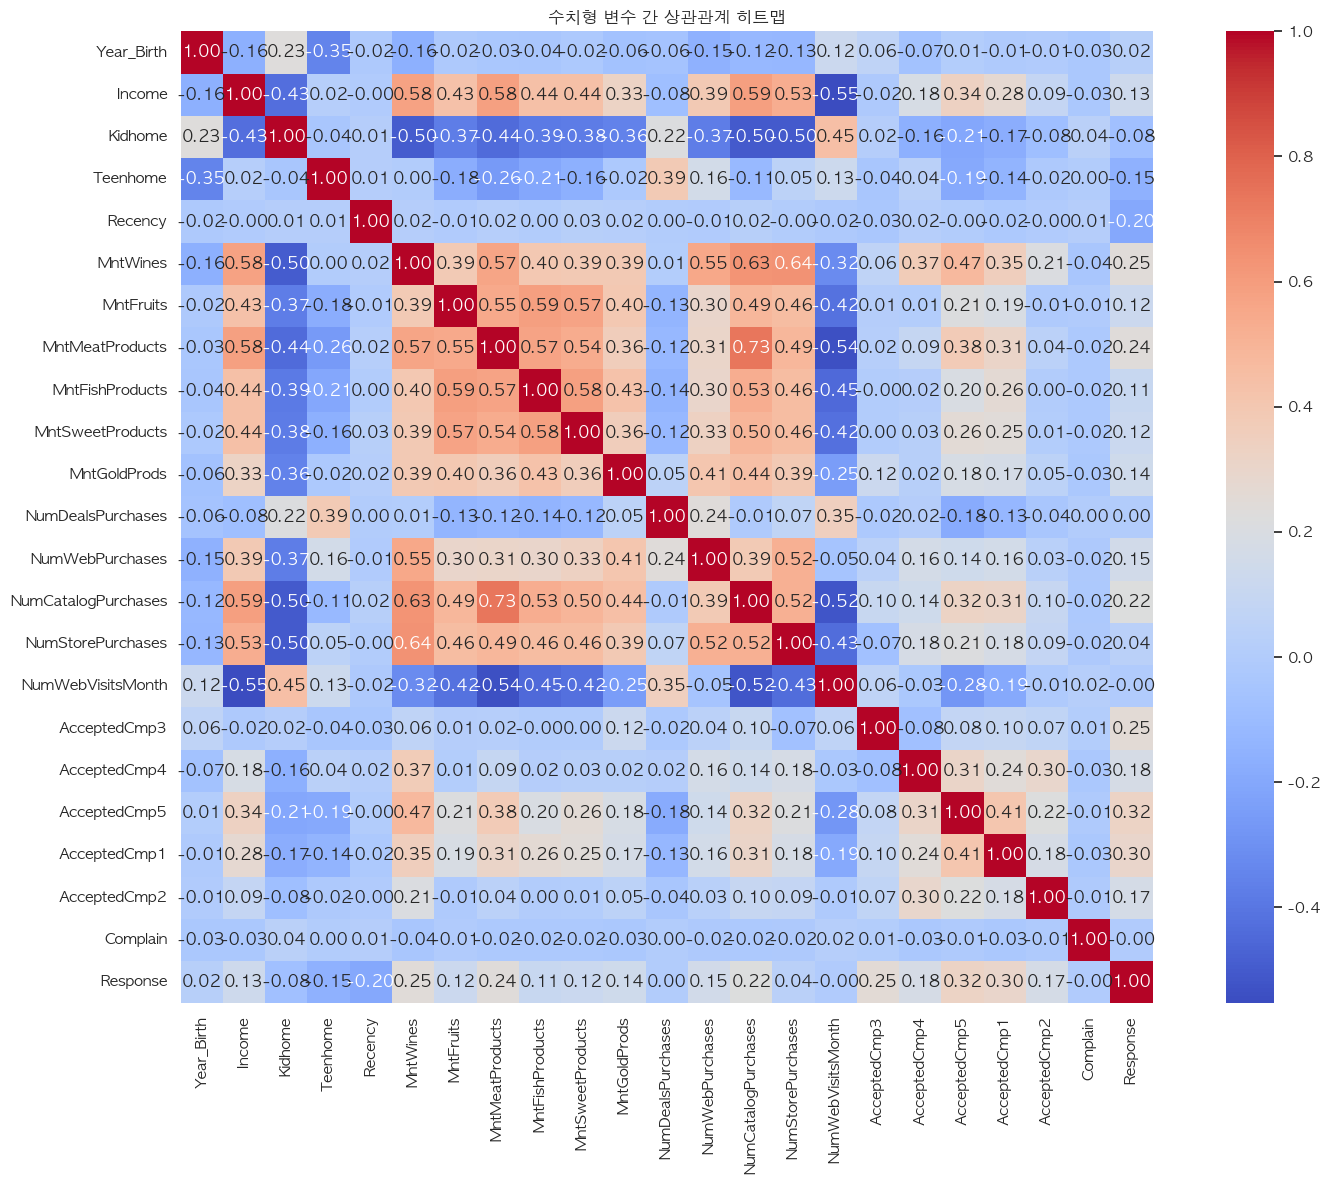

In [49]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# macOS 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False  # 음수 부호 깨짐 방지

# 수치형 변수만 추출하여 상관계수 계산
numeric_df = df_cleaned.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()

# 상관관계 히트맵 시각화
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("수치형 변수 간 상관관계 히트맵")
plt.tight_layout()
plt.show()


## EDA: 상관관계 분석 결과 요약

### 주요 상관관계 특징

- **강한 양의 상관관계**:
    - `MntWines`, `MntMeatProducts`, `MntGoldProds` 등 다양한 소비 금액 변수들끼리 강하게 양의 상관관계를 가짐 (소비력이 높은 고객이 여러 상품군을 고르게 구매함)
- **적당한 상관관계**:
    - `Income`과 `MntWines`, `MntMeatProducts` 간 양의 상관관계 존재 → 소득이 높을수록 와인, 육류 소비도 증가
- **약한 음의 상관관계**:
    - `Recency`는 대부분의 소비 변수들과 약한 음의 상관관계를 가짐 → 최근에 구매한 고객일수록 소비 지출이 약간 많음
- **`Response`와 다른 변수들의 상관관계는 전반적으로 약함**
    - 이는 통계적 유의성 검정(t-test, chi-square 등)을 통해 확인할 필요가 있음을 의미함

---

In [50]:
from scipy.stats import ttest_ind

# 두 그룹으로 나누기: Response 0 vs 1
group_0 = df_cleaned[df_cleaned['Response'] == 0]['Recency']
group_1 = df_cleaned[df_cleaned['Response'] == 1]['Recency']

# 독립표본 t-검정 수행
t_stat, p_value = ttest_ind(group_0, group_1, equal_var=False)  # Welch's t-test 적용

# 평균값 비교를 위한 출력
group_0_mean = group_0.mean()
group_1_mean = group_1.mean()

t_stat, p_value, group_0_mean, group_1_mean


(9.807580647466844,
 9.079568492350892e-21,
 51.44397238449283,
 35.26426426426426)

### [t-test 결과] `Response`에 따른 `Recency` 평균 비교

| 항목 | 값 |
| --- | --- |
| 응답자 평균 `Recency` (Response = 1) | **35.26일** |
| 비응답자 평균 `Recency` (Response = 0) | **51.44일** |
| t-통계량 | **9.81** |
| p-value | **9.08 × 10⁻²¹** (매우 작음) |

### 해석

- **귀무가설(H₀)**: 응답자와 비응답자의 `Recency` 평균은 동일함
- **대립가설(H₁)**: 두 그룹의 평균은 다름

→ **p-value가 0.05보다 훨씬 작기 때문에 귀무가설 기각**

→ 즉, **캠페인에 응답한 고객과 응답하지 않은 고객 간에 최근 구매 시점의 평균 차이가 통계적으로 유의함**

---

In [51]:
from scipy.stats import f_oneway

# 그룹별로 분리
group_0 = df_cleaned[df_cleaned['Kidhome'] == 0]['NumWebPurchases']
group_1 = df_cleaned[df_cleaned['Kidhome'] == 1]['NumWebPurchases']
group_2 = df_cleaned[df_cleaned['Kidhome'] == 2]['NumWebPurchases']

# 일원 분산 분석 (ANOVA) 수행
f_stat, p_value_anova = f_oneway(group_0, group_1, group_2)

# 각 그룹 평균값도 함께 확인
means = {
    "Kidhome = 0": group_0.mean(),
    "Kidhome = 1": group_1.mean(),
    "Kidhome = 2": group_2.mean()
}

f_stat, p_value_anova, means


(190.78955511966217,
 3.604879151334897e-77,
 {'Kidhome = 0': 4.981293842556508,
  'Kidhome = 1': 2.8602029312288613,
  'Kidhome = 2': 2.717391304347826})

### [ANOVA 결과] `Kidhome` 자녀 수에 따른 `NumWebPurchases` 평균 비교

| 그룹 | 평균 웹 구매 수 (`NumWebPurchases`) |
| --- | --- |
| 자녀 없음 (Kidhome = 0) | **4.98회** |
| 자녀 1명 (Kidhome = 1) | **2.86회** |
| 자녀 2명 (Kidhome = 2) | **2.72회** |
- **F-통계량**: 190.79
- **p-value**: 3.60 × 10⁻⁷⁷ (매우 작음)


### 해석

- **귀무가설(H₀)**: 자녀 수에 따라 웹 구매 수의 평균은 차이가 없다.
- **대립가설(H₁)**: 적어도 한 그룹에서 평균의 차이가 존재한다.

→ **p-value가 매우 작기 때문에 귀무가설 기각**

→ 즉, **자녀 수에 따라 웹 구매 횟수의 평균이 유의하게 다름**


---

In [52]:
from scipy.stats import chi2_contingency

# 교차표 생성: Education x Response
contingency_table = pd.crosstab(df_cleaned['Education'], df_cleaned['Response'])

# 카이제곱 독립성 검정
chi2_stat, p_value_chi2, dof, expected = chi2_contingency(contingency_table)

contingency_table, chi2_stat, p_value_chi2, dof


(Response      0    1
 Education           
 2n Cycle    178   22
 Basic        52    2
 Graduation  964  152
 Master      309   56
 PhD         380  101,
 23.150710092597464,
 0.00011814284716953253,
 4)

### [카이제곱 독립성 검정 결과] `Education`과 `Response` 간의 관계

| Education 수준 | Response=0 (비응답자) | Response=1 (응답자) |
| --- | --- | --- |
| 2n Cycle | 178 | 22 |
| Basic | 52 | 2 |
| Graduation | 964 | 152 |
| Master | 309 | 56 |
| PhD | 380 | 101 |
- **χ² 통계량**: 23.15
- **자유도**: 4
- **p-value**: **0.00012**

### 해석

- **귀무가설(H₀)**: 교육 수준과 캠페인 응답은 서로 독립이다.
- **대립가설(H₁)**: 교육 수준과 캠페인 응답은 서로 독립이 아니다.

→ **p-value가 0.05보다 작음 → 귀무가설 기각**

→ 즉, **교육 수준과 캠페인 응답 간에는 통계적으로 유의한 관련성이 존재**

---

## 전체 통계 분석 요약

| 분석 기법 | 변수 조합 | 유의성 | 해석 |
| --- | --- | --- | --- |
| **t-test** | `Recency` vs `Response` | p < 0.0001 | 응답자와 비응답자의 최근 구매일 평균 차이 존재 |
| **ANOVA** | `NumWebPurchases` vs `Kidhome` | p < 0.0001 | 자녀 수에 따라 웹 구매 횟수 평균 차이 존재 |
| **카이제곱** | `Education` vs `Response` | p < 0.0001 | 교육 수준과 응답 간 독립성 없음 |